# Has flying in Europe become too cheap to care about? 

Student names: Luca Verlaan (16451546), Timo Postma (16440323), Tim Snijder (16390164) en Kyano de Kleijn (16377648)

Team number: 1A

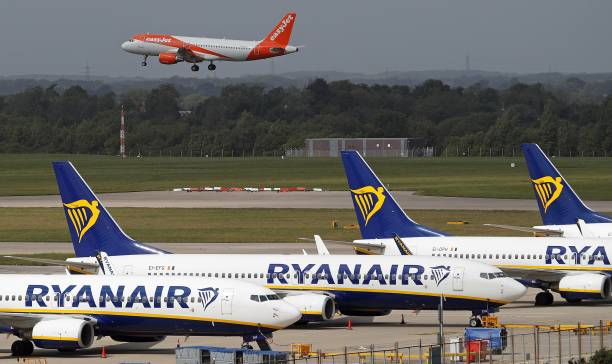

In [1]:
from IPython.display import Image, display, HTML

display(Image("gettyimages-1228118997-612x612.jpg", width=800))

display(HTML("""
<div style="width:100%; text-align:center; margin-top:10px; font-size:15px;">
    <b>Figure 1.</b> Ryanair aircraft at a European airport. <br>
"""))

---

## Introduction

In 1997, the European Union finished opening up its aviation market (Doganis, 2010). Any EU airline could from that point fly any route between member states at any price it chose. Within a decade, a handful of carriers, Ryanair, easyJet, and later Wizz Air, had built an entirely new kind of airline around this freedom. They flew between smaller secondary airports, charged for almost every extra service, and sold tickets at prices the older established carriers simply could not match. By the late 2000s, a return flight from Amsterdam to Barcelona could cost less than a train ticket across the Netherlands.

These low-cost carriers, often called LCCs, grew remarkably quickly. By 2019 they held more than half of all seats on flights within Europe, a share that was close to zero in 1995 (IATA, 2020; Dobruszkes, 2013). Ryanair alone carried over 150 million passengers that year. Together with easyJet and Wizz Air, LCCs fundamentally changed who could afford to fly and where, opening up cities and countries that were previously only connected by expensive national airline services.

Whether this transformation should be viewed as a success is less clear. On one hand, LCCs made air travel accessible to far more people and contributed to a substantial increase in passenger numbers across Europe. On the other hand, the same growth led to more flights and higher aviation emissions. This data story examines these competing perspectives and explores how the rise of low-cost carriers changed European aviation.

This story examines both sides using four datasets: three from Eurostat covering quarterly passenger and flight data for European countries and annual data for individual airports, and a fourth from EUROCONTROL giving actual measured CO₂ emissions for 44 European states from 2010 to 2025.

**None of the datasets separately label LCC from traditional carrier flights.** To compare the two groups, airports are classified as LCC-focused or traditional based on which airline dominates their traffic. The full list is in the Dataset section. This classification is a simplification and its limits are noted wherever it matters.

### Perspective 1 - LCCs make flying accessible to a broader range of people

Before LCCs, flying within Europe was expensive. National airlines like Air France, Lufthansa, and Alitalia kept fares high enough that flying was an occasional luxury for many households rather than a normal way to travel. LCCs changed this in two distinct ways. First, they pushed fares down dramatically on routes where they competed, forcing traditional carriers to reduce prices too (Vowles, 2001). Second, and more importantly for this story, they opened entirely new routes, particularly into Central and Eastern Europe, that had never been served by affordable scheduled flights before.

- **Argument 1.1:** Total EU passengers grew by roughly 46% between 2008 and 2019, faster than population or income growth alone can explain. This is not a fixed group of travellers redistributing between airlines. The total market grew substantially over the period.
- **Argument 1.2:** LCC-based airports grew at roughly double the rate of traditional hub airports between 2004 and 2019. Crucially, the traditional hubs also kept growing in absolute terms, which rules out the idea that LCCs were simply redirecting passengers from one type of airport to another.
- **Argument 1.3:** The fastest-growing national markets were in Central and Eastern Europe, exactly where Ryanair and Wizz Air were building new routes to connect cities that previously had no affordable scheduled service to Western Europe. Romania, Hungary, Poland, and the Baltic states all saw growth far above the Western European average.

### Perspective 2 - The growth in cheap flying has a real and measurable environmental cost

Flying produces CO2. More flights mean more CO₂, regardless of the ticket price. The short routes that LCCs mostly operate are also among the least fuel-efficient; a large share of total fuel is burned during take-off and climb, and shorter flights produce more emissions per kilometre than longer ones. LCCs pack more passengers per flight, which helps somewhat, but the sheer volume of extra flights they generate means the total environmental impact has kept rising.

- **Argument 2.1:** Total European aviation CO2 grew from 163 million tonnes in 2010 to 211 million tonnes in 2019, a rise of 29%. Figure 4 shows this growth tracked the rise in passenger numbers almost exactly, year after year.
- **Argument 2.2:** CO₂ per individual flight also rose during this period, from about 19 to 22 tonnes per departure. New aircraft technology improved fuel efficiency per seat, but those gains were offset by larger aircraft and more short-haul flying, so the overall per-flight footprint increased rather than fell.
- **Argument 2.3:** The countries that saw the largest passenger growth under LCC expansion also recorded the steepest increases in aviation CO2. Ireland, Poland, and Spain all grew well above the European average on both measures, showing that the access gains and the emissions increases are concentrated in exactly the same places.


---

## Dataset and Preprocessing

### How to run this notebook

Place all data files in the same folder as this notebook, then run all cells from top to bottom.

Required files:
- `avia_paoc__custom_21854155_quarterly_linear_2_0.csv`
- `avia_tf_acc__custom_21854438_quarterly_linear_2_0.csv`
- `avia_paoa__custom_21854843_linear_2_0.csv`
- `CO2_emmissions_by_state_YYYY.csv` for each year 2010 through 2025

### Datasets

| Dataset | Source | What it contains | Time range |
|---|---|---|---|
| avia_paoc | Eurostat | Quarterly passengers boarded, by country | 1993-2025, 39 countries |
| avia_tf_acc | Eurostat | Quarterly passenger flight movements, by country | 2007-2026, 39 countries |
| avia_paoa | Eurostat | Annual passengers, by airport | 2004-2025, ~350 airports |
| co2_emmissions_by_state_YYYY.csv | EUROCONTROL | Monthly CO₂ (tonnes) and flight movements, by state | 2010-2025, 44 states |

The EUROCONTROL CO₂ figures are derived from actual flight records using ICAO calculation methods. Four states (Denmark, Norway, Portugal, United Kingdom) are flagged as partially estimated in the source data. They are kept here because removing four major aviation countries would distort the European total more than retaining the estimates.

The year 2026 is excluded because only January through April data is available, making it incomparable with full-year figures.

### Airport classification

Because the Eurostat data does not separate LCC from traditional carrier traffic, airports are classified by which type of carrier dominates their operations. This proxy is imperfect: Gatwick hosts a large easyJet operation alongside British Airways, and Dublin handles Aer Lingus alongside Ryanair. These are kept in their primary classification because the dominant carrier type is consistent with the label.

The classification is based on published carrier market share data from EUROCONTROL CODA (Central Office for Delay Analysis) airport traffic digests and anna.aero airport market share reports (EUROCONTROL, 2025).

| Airport | Code | Category | Main carrier |
|---|---|---|---|
| London Stansted | UK_EGSS | LCC-focused | Ryanair |
| London Luton | UK_EGGW | LCC-focused | easyJet |
| Liverpool | UK_EGGP | LCC-focused | Ryanair |
| East Midlands | UK_EGNX | LCC-focused | Ryanair / Wizz Air |
| Bristol | UK_EGGD | LCC-focused | easyJet |
| Brussels South Charleroi | BE_EBCI | LCC-focused | Ryanair |
| Frankfurt Hahn | DE_EDFH | LCC-focused | Ryanair |
| Girona | ES_LEGE | LCC-focused | Ryanair |
| Bergamo Orio al Serio | IT_LIME | LCC-focused | Ryanair |
| Bologna | IT_LIPE | LCC-focused | Ryanair / Wizz Air |
| Dublin | IE_EIDW | LCC-focused | Ryanair |
| Lyon | FR_LFLL | LCC-focused | easyJet |
| Rotterdam | NL_EHRD | LCC-focused | Transavia |
| London Heathrow | UK_EGLL | Traditional | British Airways |
| London Gatwick | UK_EGKK | Traditional | British Airways |
| Paris CDG | FR_LFPG | Traditional | Air France |
| Frankfurt | DE_EDDF | Traditional | Lufthansa |
| Amsterdam Schiphol | NL_EHAM | Traditional | KLM |
| Madrid Barajas | ES_LEMD | Traditional | Iberia |
| Rome Fiumicino | IT_LIRF | Traditional | Alitalia / ITA |
| Munich | DE_EDDM | Traditional | Lufthansa |
| Zurich | CH_LSZH | Traditional | Swiss |
| Vienna | AT_LOWW | Traditional | Austrian |

### Preprocessing steps

1. **Eurostat files:** Only the relevant measurement columns (`PAS_BRD` for passengers, `CAF_PAS` for flight movements, and `TOTAL` transport coverage for airports) were retained. Metadata columns and rows with missing values were removed. Quarterly time codes (`YYYY-QN`) were parsed into separate year and quarter values. The four quarters were then aggregated to produce annual totals.

2. **CO₂ files:** All 16 annual files (2010–2025) were loaded and combined into a single table. The files from 2010–2018 did not contain the `FLIGHT_MONTH` column that was present in later years. This column was removed during processing, and annual CO₂ totals were calculated by summing values across all states.

3. **Growth index:** Both the passenger and CO₂ time series were indexed by dividing each value by its 2013 value and multiplying by 100. The year 2013 was chosen because it was the first year for which both datasets overlapped consistently.

4. **Country code mapping:** Eurostat used non-standard country codes such as `EL` for Greece and `UK` for the United Kingdom. These codes were converted to three-letter ISO country codes for use in the choropleth map.



In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')
import plotly.io as pio
pio.renderers.default = "notebook"
import plotly.io as pio
pio.renderers.default = "jupyterlab"

# IBM colour-blind-safe palette
COL_LCC  = '#648FFF'  # Blue   - LCC / passengers
COL_TRAD = '#FE6100'  # Orange - Traditional / flights
COL_CO2  = '#DC267F'  # Pink   - CO2 emissions
COL_EFF  = '#785EF0'  # Purple - derived efficiency metrics
COL_GREY = '#AAAAAA'
COL_GRID = '#eeeeee'

print("Imports OK.")


Imports OK.


In [3]:
# Cell 2: Load and clean the three Eurostat datasets

# avia_paoc: quarterly passengers boarded by country
raw_paoc = pd.read_csv('avia_paoc__custom_21854155_quarterly_linear_2_0.csv')
df_paoc = (
    raw_paoc[raw_paoc['tra_meas'] == 'PAS_BRD']
    [['geo', 'Geopolitical entity (reporting)', 'TIME_PERIOD', 'OBS_VALUE']]
    .rename(columns={
        'geo': 'country_code',
        'Geopolitical entity (reporting)': 'country_name',
        'OBS_VALUE': 'passengers'
    })
    .dropna(subset=['passengers'])
    .copy()
)
df_paoc['year']    = df_paoc['TIME_PERIOD'].str[:4].astype(int)
df_paoc['quarter'] = df_paoc['TIME_PERIOD'].str[-1].astype(int)
df_paoc_annual = df_paoc.groupby(
    ['country_code', 'country_name', 'year'], as_index=False
)['passengers'].sum()

# avia_tf_acc: quarterly passenger flight movements by country
raw_tf = pd.read_csv('avia_tf_acc__custom_21854438_quarterly_linear_2_0.csv')
df_tf = (
    raw_tf[raw_tf['tra_meas'] == 'CAF_PAS']
    [['geo', 'Geopolitical entity (reporting)', 'TIME_PERIOD', 'OBS_VALUE']]
    .rename(columns={
        'geo': 'country_code',
        'Geopolitical entity (reporting)': 'country_name',
        'OBS_VALUE': 'flights'
    })
    .dropna(subset=['flights'])
    .copy()
)
df_tf['year']    = df_tf['TIME_PERIOD'].str[:4].astype(int)
df_tf['quarter'] = df_tf['TIME_PERIOD'].str[-1].astype(int)
df_tf_annual = df_tf.groupby(
    ['country_code', 'country_name', 'year'], as_index=False
)['flights'].sum()

# avia_paoa: annual passengers by airport
raw_paoa = pd.read_csv('avia_paoa__custom_21854843_linear_2_0.csv', low_memory=False)
df_paoa = (
    raw_paoa[
        (raw_paoa['tra_meas'] == 'PAS_BRD') &
        (raw_paoa['tra_cov']  == 'TOTAL')
    ]
    [['rep_airp', 'Reporting airport', 'TIME_PERIOD', 'OBS_VALUE']]
    .rename(columns={
        'rep_airp': 'airport_code',
        'Reporting airport': 'airport_name',
        'OBS_VALUE': 'passengers'
    })
    .copy()
)
df_paoa['passengers']   = pd.to_numeric(df_paoa['passengers'], errors='coerce')
df_paoa['TIME_PERIOD']  = df_paoa['TIME_PERIOD'].astype(int)
df_paoa['country_code'] = df_paoa['airport_code'].str[:2]
df_paoa.dropna(subset=['passengers'], inplace=True)

EU_AGGREGATES = {'EU27_2007', 'EU27_2020', 'EU28'}

# Airport classification
LCC_AIRPORTS = {
    'UK_EGSS': 'London Stansted', 'UK_EGGW': 'London Luton',
    'UK_EGGP': 'Liverpool',       'UK_EGNX': 'East Midlands',
    'UK_EGGD': 'Bristol',         'BE_EBCI': 'Brussels South Charleroi',
    'DE_EDFH': 'Frankfurt Hahn',  'ES_LEGE': 'Girona',
    'IT_LIME': 'Bergamo',         'IT_LIPE': 'Bologna',
    'IE_EIDW': 'Dublin',          'FR_LFLL': 'Lyon',
    'NL_EHRD': 'Rotterdam',
}
TRAD_AIRPORTS = {
    'UK_EGLL': 'London Heathrow', 'UK_EGKK': 'London Gatwick',
    'FR_LFPG': 'Paris CDG',       'DE_EDDF': 'Frankfurt',
    'NL_EHAM': 'Amsterdam Schiphol', 'ES_LEMD': 'Madrid Barajas',
    'IT_LIRF': 'Rome Fiumicino',  'DE_EDDM': 'Munich',
    'CH_LSZH': 'Zurich',          'AT_LOWW': 'Vienna',
}
type_map   = {k: 'LCC-focused' for k in LCC_AIRPORTS}
type_map.update({k: 'Traditional' for k in TRAD_AIRPORTS})
label_map  = {**LCC_AIRPORTS, **TRAD_AIRPORTS}
df_paoa['airport_type']  = df_paoa['airport_code'].map(type_map)
df_paoa['airport_label'] = df_paoa['airport_code'].map(label_map)

print("Eurostat datasets loaded.")
print(f"  paoc: {df_paoc_annual.shape[0]:,} rows  ({df_paoc_annual.year.min()}-{df_paoc_annual.year.max()})")
print(f"  tf:   {df_tf_annual.shape[0]:,} rows  ({df_tf_annual.year.min()}-{df_tf_annual.year.max()})")
print(f"  paoa: {df_paoa.shape[0]:,} rows  ({df_paoa.TIME_PERIOD.min()}-{df_paoa.TIME_PERIOD.max()})")


Eurostat datasets loaded.
  paoc: 823 rows  (1993-2025)
  tf:   520 rows  (2007-2026)
  paoa: 9,665 rows  (2004-2025)


In [4]:
# Cell 3: Load and combine EUROCONTROL CO₂ files (2010-2025)
# 2026 is excluded: only January-April data available.

co2_dfs = []
for year in range(2010, 2026):
    fpath = f'co2_emmissions_by_state_{year}.csv'
    if os.path.exists(fpath):
        co2_dfs.append(pd.read_csv(fpath))

co2_raw   = pd.concat(co2_dfs, ignore_index=True)
co2_clean = co2_raw[['YEAR', 'MONTH', 'STATE_NAME', 'CO2_QTY_TONNES', 'TF']].copy()
co2_clean.dropna(subset=['CO2_QTY_TONNES', 'TF'], inplace=True)

# Annual totals across all ECAC states
co2_annual = (
    co2_clean
    .groupby('YEAR', as_index=False)
    .agg(
        co2_Mt    = ('CO2_QTY_TONNES', lambda x: x.sum() / 1e6),
        tf_total  = ('TF', 'sum')
    )
)
co2_annual['co2_per_flight'] = (co2_annual['co2_Mt'] * 1e6) / co2_annual['tf_total']

print(f"CO2 dataset loaded: {co2_raw.shape[0]:,} rows, {co2_clean.YEAR.min()}-{co2_clean.YEAR.max()}")
print(f"States covered: {co2_clean.STATE_NAME.nunique()}")
print()
print(co2_annual[['YEAR', 'co2_Mt', 'co2_per_flight']].to_string(index=False))


CO2 dataset loaded: 8,122 rows, 2010-2025
States covered: 44

 YEAR     co2_Mt  co2_per_flight
 2010 163.151391       19.323982
 2011 171.312130       19.580118
 2012 166.143012       19.574389
 2013 166.976285       20.007192
 2014 174.153434       20.389727
 2015 178.804171       20.510835
 2016 187.211237       20.884981
 2017 196.197021       21.193296
 2018 205.424355       21.494579
 2019 210.716354       21.959529
 2020  90.840907       20.780350
 2021 108.798802       20.067963
 2022 170.730482       20.849150
 2023 194.888958       21.864615
 2024 210.427650       22.560132
 2025 220.092943       22.832632


---
## Perspective 1 - LCCs make flying accessible to a broader range of people



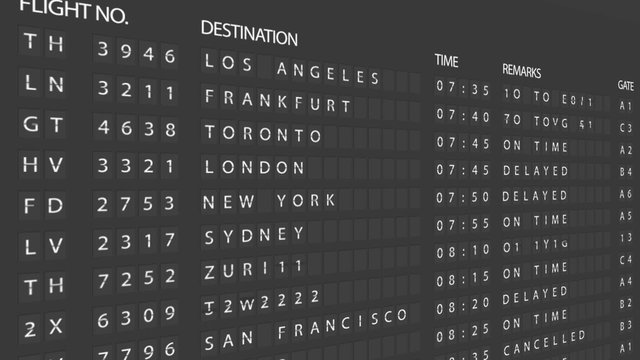

In [5]:
from IPython.display import Image, display, HTML

display(Image("360_F_79969247_akMrI7uMn62718WhWGQg8Bpb8cRE5nPW.jpg", width=900))

display(HTML("""
<div style="width:100%; text-align:center; margin-top:10px; font-size:15px;">
    <b>Figure 2.</b> Airport departure board.<br>
"""))

Something worth establishing up front: this is not only a historical story. LCCs are still operating, still opening new routes, and still pricing out competitors. Ryanair set a new passenger record in 2023. The market expansion documented here has not stopped.

The case that LCCs broadened access to air travel rests on three connected observations. First, total passenger numbers grew far beyond what existing airlines could have absorbed alone, which suggests new demand was created rather than redistributed. Second, the airports that LCCs used as their bases grew at roughly double the rate of traditional hubs, and the traditional hubs kept growing too, which rules out simple redistribution. Third, the growth was geographically concentrated in the countries where LCCs expanded most aggressively, which is exactly where you would expect the access effect to be largest.

The three visualisations that follow examine each of these observations in turn.



### Argument 1.1 - Total EU27 air travel grew substantially between 2008 and 2019

The chart below shows the annual number of passengers boarding flights in the EU27 alongside the total number of passenger flight movements. The EU27 refers to the 27 member states of the European Union.

Displaying both together is more informative than either alone. Passenger numbers show how demand changed. Flight movements show how much aircraft activity that demand required. If passengers grew much faster than flights, it means the existing capacity was being filled more efficiently. If both grew in step, the market expanded but did not become more efficient.


In [6]:
eu_pax = (
    df_paoc[df_paoc['country_code'] == 'EU27_2020']
    .groupby('year')['passengers'].sum().reset_index()
)
eu_pax = eu_pax[(eu_pax['year'] >= 2008) & (eu_pax['year'] <= 2024)]

eu_flt = (
    df_tf[df_tf['country_code'] == 'EU27_2020']
    .groupby('year')['flights'].sum().reset_index()
)
eu_flt = eu_flt[(eu_flt['year'] >= 2008) & (eu_flt['year'] <= 2024)]

fig1 = make_subplots(specs=[[{'secondary_y': True}]])

fig1.add_trace(go.Scatter(
    x=eu_pax['year'], y=eu_pax['passengers'] / 1e6,
    name='Passengers boarded (billions)',
    mode='lines+markers',
    line=dict(color=COL_LCC, width=2.5),
    marker=dict(size=7),
    hovertemplate='%{x}: %{y:.2f}B passengers<extra></extra>'
), secondary_y=False)

fig1.add_trace(go.Scatter(
    x=eu_flt['year'], y=eu_flt['flights'] / 1e6,
    name='Commercial flights (millions)',
    mode='lines+markers',
    line=dict(color=COL_TRAD, width=2.5, dash='dash'),
    marker=dict(size=7),
    hovertemplate='%{x}: %{y:.2f}M flights<extra></extra>'
), secondary_y=True)

fig1.add_vrect(
    x0=2019.6, x1=2021.4, fillcolor='rgba(180,180,180,0.25)',
    line_width=0, annotation_text='COVID-19',
    annotation_position='top left',
    annotation_font=dict(size=11, color='#888888')
)
fig1.add_vline(
    x=2009, line_dash='dot', line_color='#cccccc', line_width=1.5,
    annotation_text='GFC dip', annotation_position='top right',
    annotation_font=dict(size=10, color='#aaaaaa')
)

fig1.update_layout(
    title=dict(
        text=(
            '<b>EU27 Air Travel, 2008-2024</b><br>'
            '<sup>Passengers boarded (left axis, millions) and commercial flight movements '
            '(right axis, millions). Source: Eurostat avia_paoc, avia_tf_acc.</sup>'
        ),
        font=dict(size=15)
    ),
    height=460, plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    hovermode='x unified',
    xaxis=dict(title='Year', tickmode='linear', tick0=2008, dtick=2, showgrid=False)
)
fig1.update_yaxes(title_text='Passengers (millions)', secondary_y=False,
                  showgrid=True, gridcolor=COL_GRID)
fig1.update_yaxes(title_text='Flights (millions)', secondary_y=True, showgrid=False)
fig1.show()

p08 = eu_pax.loc[eu_pax['year'] == 2008, 'passengers'].values[0]
p19 = eu_pax.loc[eu_pax['year'] == 2019, 'passengers'].values[0]
f08 = eu_flt.loc[eu_flt['year'] == 2008, 'flights'].values[0]
f19 = eu_flt.loc[eu_flt['year'] == 2019, 'flights'].values[0]
print(f"Passengers: {p08/1e9:.2f}B (2008) to {p19/1e9:.2f}B (2019)  (+{(p19/p08-1)*100:.0f}%)")
print(f"Flights:    {f08/1e6:.2f}M (2008) to {f19/1e6:.2f}M (2019)  (+{(f19/f08-1)*100:.0f}%)")
print(f"Passengers per flight 2008: {p08/f08:.1f}   2019: {p19/f19:.1f}")


Passengers: 0.71B (2008) to 1.04B (2019)  (+46%)
Flights:    9.45M (2008) to 10.19M (2019)  (+8%)
Passengers per flight 2008: 75.1   2019: 101.8


**Figure 1 - EU27 Air Passengers and Flights, 2008-2024.** The blue line shows strong growth in air travel demand: from 710 million passengers in 2008 to 1040 million in 2019, a rise of 46% in eleven years. Such an increase suggests that the European aviation market was expanding rather than remaining static. The orange dashed line, showing flight movements, grew by only 8% over the same period. That gap is significant. In 2008 the average departure carried about 75 passengers. By 2019 that had risen to 102. LCCs targeting load factors above 90% contributed directly to this; airlines were filling their planes much more aggressively than before.

The small 2009 dip can be explained by the Global Financial Crisis. One year of contraction, then recovery, which was faster than almost any other sector of the economy managed. Cheap fares turned out to be relatively recession-proof. The COVID-19 collapse in 2020 was different in kind, not just in scale. Roughly 70% of all air travel evaporated in a single year. The recovery from 2021 onward brought both lines back close to their 2019 positions by 2024, with 2023 matching the pre-pandemic passenger total almost exactly.

What the chart leaves unanswered is whether that 46% growth represented new travellers or just a reshuffling of existing ones. If LCCs only pulled passengers away from Air France and Lufthansa, the total market should not have grown much at all. The next chart goes directly to that question.

### Argument 1.2 - LCC-based airports grew at double the rate of traditional hubs

The simplest test of whether LCCs grew the market or redistributed it is to look at what happened to the airports they did not use. If cheap airlines were taking passengers from Heathrow and CDG, those airports should have declined or at least stagnated. If both airport types grew, the market expanded.


In [7]:
growth_rows = []
for ap_code, label in label_map.items():
    atype = type_map.get(ap_code)
    p04 = df_paoa[(df_paoa['airport_code'] == ap_code) & (df_paoa['TIME_PERIOD'] == 2004)]['passengers']
    p19 = df_paoa[(df_paoa['airport_code'] == ap_code) & (df_paoa['TIME_PERIOD'] == 2019)]['passengers']
    if len(p04) > 0 and len(p19) > 0:
        pct = (p19.values[0] / p04.values[0] - 1) * 100
        growth_rows.append({'label': label, 'atype': atype, 'pct_growth': round(pct, 1)})

growth_df = pd.DataFrame(growth_rows)
# Drop airports with negative growth (Ryanair base relocations, not market decline)
growth_df = growth_df[growth_df['pct_growth'] >= 0]
# Sort by growth descending so LCC airports rise to the top
growth_df = growth_df.sort_values('pct_growth', ascending=True)

colors = [COL_LCC if t == 'LCC-focused' else COL_TRAD for t in growth_df['atype']]

fig2 = go.Figure()

# Main data bars - showlegend=False to avoid 'Trace 0' appearing in legend
fig2.add_trace(go.Bar(
    x=growth_df['pct_growth'],
    y=growth_df['label'],
    orientation='h',
    marker_color=colors,
    text=[f'+{v:.0f}%' for v in growth_df['pct_growth']],
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Growth: +%{x:.0f}%<extra></extra>',
    cliponaxis=False,
    showlegend=False,
    name=''
))

# Named dummy bars for the legend only
for lbl, col in [('LCC-focused', COL_LCC), ('Traditional', COL_TRAD)]:
    fig2.add_trace(go.Bar(
        x=[None], y=[None], orientation='h',
        marker_color=col, name=lbl, showlegend=True
    ))

fig2.update_layout(
    title=dict(
        text=(
            '<b>Passenger Growth at Classified Airports, 2004-2019</b><br>'
            '<sup>Percentage growth in annual passengers boarded. '
            'Blue = LCC-focused, Orange = Traditional. '
            'Source: Eurostat avia_paoa.</sup>'
        ),
        font=dict(size=15)
    ),
    xaxis=dict(
        title='Passenger growth (%)',
        showgrid=True, gridcolor=COL_GRID,
        range=[0, 400]
    ),
    yaxis=dict(title='', automargin=True),
    height=560,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(r=80),
    legend=dict(
        orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1
    ),
)
fig2.show()

lcc_med = growth_df[growth_df['atype']=='LCC-focused']['pct_growth'].median()
trd_med = growth_df[growth_df['atype']=='Traditional']['pct_growth'].median()
print(f"Median growth - LCC-focused: +{lcc_med:.0f}%   Traditional: +{trd_med:.0f}%")


Median growth - LCC-focused: +91%   Traditional: +55%


**Figure 2 - Passenger Growth at Classified Airports, 2004-2019.** Looking at the airports near the top of the chart; Brussels South Charleroi grew by more than 300%. Bergamo grew by more than 300%. Bologna, an airport that barely featured in European aviation two decades ago, grew by 225%. London Luton by 141%. These are not airports that benefited from economic growths in their cities. They grew because LCCs chose them as operational bases and proceeded to run hundreds of routes out of them.

Looking towards the bottom; Heathrow grew 20%, CDG grew 49%, Frankfurt grew 37%. Every single traditional airport in this chart shows positive growth. This matters because it rules out the most sceptical interpretation of what LCCs did: that they simply relocated demand from established hubs to secondary airports. If that were true, those orange bars would be showing reduction or be barely visible. Instead they are substantial. The total market grew, and it grew for both types of airport.

Two LCC airports are missing from the chart: Frankfurt Hahn and Girona. Both saw passenger numbers fall between 2004 and 2019. In Hahn's case, Ryanair progressively reduced operations there as it shifted focus toward larger German cities. Girona similarly lost traffic as Ryanair opened Barcelona El Prat services instead. Their decline is a story about airline strategy, not market weakness, and including them would have obscured the broader picture.

### Argument 1.3 - Growth was strongest where LCCs expanded most

The total EU numbers and the airport-level picture both point in the same direction: LCCs grew the market, but they did not grow it evenly. To see where the growth actually landed, and whether it matches the documented geography of LCC expansion, the map below traces how each European country's passenger numbers changed relative to 2004. Use the slider or press 'Play' to watch the years unfold.


In [8]:
country_data = df_paoc_annual[
    ~df_paoc_annual['country_code'].isin(EU_AGGREGATES)
].copy()

base_pax = (
    country_data[country_data['year'] == 2004]
    [['country_code', 'passengers']]
    .rename(columns={'passengers': 'pax_base'})
)
country_data = country_data.merge(base_pax, on='country_code', how='left')
country_data['growth_index'] = (country_data['passengers'] / country_data['pax_base']) * 100

estat_to_iso3 = {
    'AT':'AUT','BE':'BEL','BG':'BGR','CH':'CHE','CY':'CYP','CZ':'CZE',
    'DE':'DEU','DK':'DNK','EE':'EST','EL':'GRC','ES':'ESP','FI':'FIN',
    'FR':'FRA','HR':'HRV','HU':'HUN','IE':'IRL','IS':'ISL','IT':'ITA',
    'LT':'LTU','LU':'LUX','LV':'LVA','ME':'MNE','MK':'MKD','MT':'MLT',
    'NL':'NLD','NO':'NOR','PL':'POL','PT':'PRT','RO':'ROU','RS':'SRB',
    'SE':'SWE','SI':'SVN','SK':'SVK','TR':'TUR','UK':'GBR','BA':'BIH'
}
country_data['iso3'] = country_data['country_code'].map(estat_to_iso3)
country_data.dropna(subset=['iso3', 'growth_index', 'pax_base'], inplace=True)

years_range = sorted([y for y in country_data['year'].unique() if 2005 <= y <= 2024])

frames = []
for yr in years_range:
    d = country_data[country_data['year'] == yr]
    frames.append(go.Frame(
        data=[go.Choropleth(
            locations=d['iso3'], z=d['growth_index'],
            customdata=d[['country_name','passengers','growth_index']].values,
            hovertemplate=(
                '<b>%{customdata[0]}</b><br>'
                'Passengers: %{customdata[1]:,.0f}<br>'
                'Index (2004=100): %{customdata[2]:.0f}'
                '<extra></extra>'
            ),
            colorscale='Blues', zmin=40, zmax=400,
            colorbar=dict(title='Index<br>(2004=100)', len=0.65)
        )],
        name=str(yr)
    ))

init = country_data[country_data['year'] == 2019]
fig3 = go.Figure(
    data=[go.Choropleth(
        locations=init['iso3'], z=init['growth_index'],
        customdata=init[['country_name','passengers','growth_index']].values,
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Passengers: %{customdata[1]:,.0f}<br>'
            'Index (2004=100): %{customdata[2]:.0f}'
            '<extra></extra>'
        ),
        colorscale='Blues', zmin=40, zmax=400,
        colorbar=dict(title='Index<br>(2004=100)', len=0.65)
    )],
    frames=frames
)

slider_steps = [
    dict(
        args=[[str(yr)], dict(frame=dict(duration=350, redraw=True), mode='immediate')],
        label=str(yr), method='animate'
    )
    for yr in years_range
]

fig3.update_layout(
    title=dict(
        text=(
            '<b>European Air Passenger Growth by Country (Index, 2004 = 100)</b><br>'
            '<sup>Darker blue = stronger growth relative to 2004. '
            'Use the slider or press Play to animate. Hover for country detail. '
            'Source: Eurostat avia_paoc.</sup>'
        ),
        font=dict(size=15)
    ),
    geo=dict(
        scope='europe', projection_type='natural earth',
        showland=True, landcolor='#f5f5f5',
        showcoastlines=True, coastlinecolor='#cccccc', showframe=False
    ),
    height=570, paper_bgcolor='white',
    sliders=[dict(
        active=years_range.index(2019), steps=slider_steps,
        x=0.05, len=0.90,
        currentvalue=dict(prefix='Year: ', font=dict(size=14))
    )],
    updatemenus=[dict(
        type='buttons', showactive=False, y=0.02, x=0.05,
        buttons=[
            dict(label='Play', method='animate',
                 args=[None, dict(frame=dict(duration=400, redraw=True), fromcurrent=True)]),
            dict(label='Pause', method='animate',
                 args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
        ]
    )]
)
fig3.show()

top8 = (
    country_data[country_data['year'] == 2019]
    [['country_name', 'growth_index']]
    .sort_values('growth_index', ascending=False)
    .head(8)
)
print("Top 8 countries by 2019 passenger growth (index, 2004=100):")
print(top8.to_string(index=False))


Top 8 countries by 2019 passenger growth (index, 2004=100):
country_name  growth_index
      Poland    770.902710
      Latvia    735.396467
     Romania    628.728866
     Iceland    401.588049
     Estonia    328.865758
    Portugal    287.191848
       Malta    264.680766
     Hungary    262.218159


**Figure 3 - European Passenger Growth by Country, 2005-2024 (interactive).** Romania, Hungary, Poland, and the Baltic states turn dark almost immediately and keep deepening through the 2010s. These are the countries where Wizz Air launched and where Ryanair aggressively expanded its eastern network, connecting cities like Krakow, Cluj-Napoca, and Vilnius to Western Europe for fares that had no precedent (Dobruszkes, 2013; Francis et al., 2006). Before those routes existed, a Polish student wanting to fly to London would have faced national carrier pricing that put the trip beyond reach for most families.

Western Europe, by contrast, stays relatively lighter. France, Germany, the Netherlands, and Belgium show moderate growth, not because their markets stagnated, but because they started from a much higher base and their capacity was already largely built out before LCCs arrived. Ireland is a notable exception: it turns dark quickly, which makes sense given that Ryanair is headquartered in Dublin and uses Dublin Airport as its primary hub.

---

## The link between the two perspectives

The evidence so far suggests that low-cost carriers helped expand air travel across Europe, particularly in Central and Eastern Europe. That naturally raises the next question: what was the environmental cost of that growth?

The increase in passenger numbers and the increase in emissions are closely connected. Every additional passenger requires capacity, and that capacity ultimately translates into aircraft movements, fuel consumption, and CO₂ emissions. When Bergamo grew from 3 million to 14 million passengers over fifteen years, that was not only a story about Italian families flying to London for sixty euros. It was also a story about tens of thousands of additional aircraft movements per year from a single airport, each consuming fuel and producing emissions. The same pattern applies across Europe. As low-cost carriers expanded routes and attracted new passengers, both passenger totals and aviation emissions increased (Eurostat, 2025).

Figure 4 examines that relationship directly by comparing passenger growth and CO₂ emissions on the same scale. If the rise of low-cost carriers expanded the market, it is expected both measures move upward together.





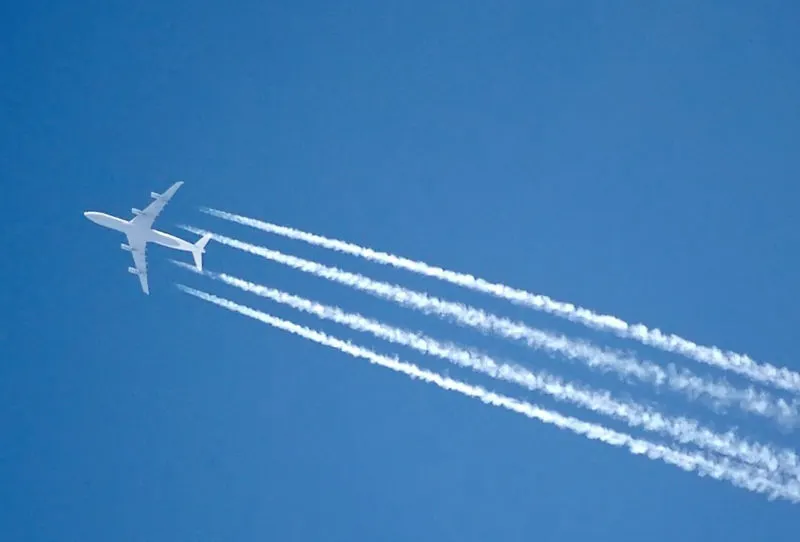

In [9]:
from IPython.display import Image, display, HTML

display(Image("Contrail1.png", width=900))

display(HTML("""
<div style="width:100%; text-align:center; margin-top:10px; font-size:15px;">
    <b>Figure 3.</b> Aircraft contrails visible in the upper atmosphere.<br>
</div>
"""))

## Perspective 2 - The growth in cheap flying has a real and measurable environmental cost

Flying produces CO₂. More flights mean more CO₂, regardless of the ticket price, and regardless of which airline operates the route. The three charts below examine how much European aviation emissions grew during the same period that LCCs were expanding the passenger market, and whether aircraft technology improvements made any meaningful dent in the trajectory.

It is worth being precise about how Arguments 2.1 and 2.2 differ. Argument 2.1 is about total emissions: the absolute amount of CO₂ released by European aviation each year went up. Argument 2.2 is about emissions per flight: even setting aside the growth in volume, each individual flight was not getting cleaner fast enough to matter. Both arguments point in the same direction, but they identify different mechanisms.

### Argument 2.1 - Total CO₂ rose in step with total passenger growth

Both passenger numbers and CO₂ emissions are indexed here to 100 in 2013, the first year where the EUROCONTROL emissions data and the Eurostat passenger data overlap cleanly. By anchoring both to the same starting point, you can see which grew faster and by how much, without having to convert between units or choose an arbitrary scale. A value of 120 means 20% more compared to 2013.

In [10]:
eu_pax_yr = (
    df_paoc[df_paoc['country_code'] == 'EU27_2020']
    .groupby('year')['passengers'].sum().reset_index()
    .rename(columns={'year': 'YEAR', 'passengers': 'pax_eu'})
)

idx_df = eu_pax_yr.merge(co2_annual[['YEAR', 'co2_Mt']], on='YEAR', how='inner')
idx_df = idx_df[(idx_df['YEAR'] >= 2013) & (idx_df['YEAR'] <= 2025)]

base_pax = idx_df.loc[idx_df['YEAR'] == 2013, 'pax_eu'].values[0]
base_co2 = idx_df.loc[idx_df['YEAR'] == 2013, 'co2_Mt'].values[0]
idx_df['pax_index'] = idx_df['pax_eu'] / base_pax * 100
idx_df['co2_index'] = idx_df['co2_Mt'] / base_co2 * 100

fig4 = go.Figure()

fig4.add_trace(go.Scatter(
    x=idx_df['YEAR'], y=idx_df['pax_index'],
    name='EU27 passengers (index)',
    mode='lines+markers',
    line=dict(color=COL_LCC, width=2.5), marker=dict(size=7),
    hovertemplate='%{x}: index = %{y:.1f}<extra>Passengers</extra>'
))

fig4.add_trace(go.Scatter(
    x=idx_df['YEAR'], y=idx_df['co2_index'],
    name='European aviation CO2 (index)',
    mode='lines+markers',
    line=dict(color=COL_CO2, width=2.5, dash='dot'), marker=dict(size=7),
    hovertemplate='%{x}: index = %{y:.1f}<extra>CO2</extra>'
))

fig4.add_hline(
    y=100, line_dash='dash', line_color='#aaaaaa', line_width=1,
    annotation_text='2013 baseline', annotation_position='right',
    annotation_font=dict(size=9, color='#aaaaaa')
)
fig4.add_vrect(
    x0=2019.6, x1=2021.4, fillcolor='rgba(180,180,180,0.2)', line_width=0,
    annotation_text='COVID-19', annotation_position='top left',
    annotation_font=dict(size=10, color='#888888')
)

fig4.update_layout(
    title=dict(
        text=(
            '<b>Passenger Growth versus Aviation CO2 Growth, 2013-2025</b><br>'
            '<sup>Both series indexed to 2013 = 100. '
            'CO2: EUROCONTROL (all ECAC states). '
            'Passengers: Eurostat avia_paoc (EU27).</sup>'
        ),
        font=dict(size=15)
    ),
    height=470, plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(
        title='Year', tickmode='linear', tick0=2013, dtick=1, showgrid=False
    ),
    yaxis=dict(title='Index (2013 = 100)', showgrid=True, gridcolor=COL_GRID),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    hovermode='x unified'
)
fig4.show()

co2_13 = co2_annual.loc[co2_annual['YEAR']==2013, 'co2_Mt'].values[0]
co2_19 = co2_annual.loc[co2_annual['YEAR']==2019, 'co2_Mt'].values[0]
co2_25 = co2_annual.loc[co2_annual['YEAR']==2025, 'co2_Mt'].values[0]
pax_19 = idx_df.loc[idx_df['YEAR']==2019, 'pax_index'].values[0]
co2_19_idx = idx_df.loc[idx_df['YEAR']==2019, 'co2_index'].values[0]
print(f"2019: passenger index = {pax_19:.1f},  CO2 index = {co2_19_idx:.1f}")
print(f"CO2 in actual numbers: {co2_13:.1f}Mt (2013) to {co2_19:.1f}Mt (2019)  (+{(co2_19/co2_13-1)*100:.0f}%)")
print(f"CO2 in 2025: {co2_25:.1f}Mt  (a new record, +{(co2_25/co2_13-1)*100:.0f}% vs 2013)")


2019: passenger index = 138.4,  CO2 index = 126.2
CO2 in actual numbers: 167.0Mt (2013) to 210.7Mt (2019)  (+26%)
CO2 in 2025: 220.1Mt  (a new record, +32% vs 2013)


**Figure 4 - Passenger Growth versus Aviation CO₂ Growth, 2013-2025.** The two lines are hard to tell apart through most of the pre-COVID period. From 2013 to 2019, EU27 passengers grew to about 138 on the index while European aviation CO₂ output grew to about 126. The number of passengers grew slightly faster than emissions, which reflects the load factor improvement seen in Figure 1: planes were filling up a bit more, so each tonne of CO2 was being shared across slightly more people. Nevertheless, the gap between the lines is small. European aviation became 26% more polluting between 2013 and 2019. In absolute terms that means going from 167 million tonnes to 211 million tonnes of CO2, an increase of 44 million tonnes. This is roughly the total annual CO2 output of a country the size of Denmark (European Environment Agency [EEA], 2022).

One caveat is worth stating before reading too much into the chart. The CO2 data comes from EUROCONTROL, which collects figures for all 44 ECAC member states. ECAC, the European Civil Aviation Conference, is a broader grouping than the EU: it includes Norway, Switzerland, Turkey, Ukraine, and other non-EU countries that share European airspace. The Eurostat passenger data, on the other hand, covers only the EU27. The two series are not measuring exactly the same geography, which is why only the growth rates are being compared here, not the absolute levels. On that basis the comparison is valid.

By 2025, the CO2 line sits above its pre-pandemic peak, reaching a new record of 220 million tonnes. The trajectory that COVID interrupted has resumed exactly where it left off.

### Argument 2.2 - CO2 per individual flight rose, not fell

If airlines had been replacing old aircraft with newer, cleaner models fast enough to matter at the system level, CO2 per flight movement should have been falling throughout this period. This is a different claim from Argument 2.1: it is not about the total volume of emissions, but about whether each individual flight was becoming cleaner. The lower panel of the next chart tests whether that actually happened.


In [11]:
plot_years = co2_annual[
    (co2_annual['YEAR'] >= 2010) & (co2_annual['YEAR'] <= 2025)
].copy()

fig5 = make_subplots(
    rows=2, cols=1,
    row_heights=[0.58, 0.42],
    vertical_spacing=0.14,
    subplot_titles=(
        'Total European aviation CO2 (megatonnes)',
        'CO2 per flight movement (tonnes per flight)'
    )
)

bar_colors = [
    COL_CO2 if yr <= 2019 else
    ('#CCCCCC' if yr <= 2021 else '#DC267F')
    for yr in plot_years['YEAR']
]

fig5.add_trace(go.Bar(
    x=plot_years['YEAR'], y=plot_years['co2_Mt'],
    name='Total CO2 (Mt)', marker_color=bar_colors,
    hovertemplate='%{x}: %{y:.1f} Mt CO2<extra></extra>'
), row=1, col=1)

fig5.add_annotation(
    x=2020, y=95, text='COVID<br>collapse',
    showarrow=True, arrowhead=2, arrowcolor='#999999',
    ax=0, ay=-30, font=dict(size=9, color='#666666'),
    row=1, col=1
)

fig5.add_trace(go.Scatter(
    x=plot_years['YEAR'], y=plot_years['co2_per_flight'],
    name='CO2 per flight', mode='lines+markers',
    line=dict(color=COL_EFF, width=2.5), marker=dict(size=7),
    hovertemplate='%{x}: %{y:.1f} t/flight<extra></extra>'
), row=2, col=1)

fig5.update_layout(
    title=dict(
        text=(
            '<b>European Aviation CO2: Total and Per Flight, 2010-2025</b><br>'
            '<sup>Source: EUROCONTROL CO2 emissions by ECAC state. '
            'All 44 reporting states included. '
            'Faded bars = post-COVID recovery period.</sup>'
        ),
        font=dict(size=15)
    ),
    height=600, plot_bgcolor='white', paper_bgcolor='white', showlegend=False
)
fig5.update_xaxes(showgrid=False, tickmode='linear', tick0=2010, dtick=2)
fig5.update_yaxes(title_text='CO2 (megatonnes)', row=1, col=1,
                  showgrid=True, gridcolor=COL_GRID)
fig5.update_yaxes(title_text='Tonnes CO2 per flight', row=2, col=1,
                  showgrid=True, gridcolor=COL_GRID)
fig5.show()

e10 = plot_years.loc[plot_years['YEAR']==2010, 'co2_per_flight'].values[0]
e19 = plot_years.loc[plot_years['YEAR']==2019, 'co2_per_flight'].values[0]
e25 = plot_years.loc[plot_years['YEAR']==2025, 'co2_per_flight'].values[0]
print(f"CO2 per flight: {e10:.1f}t (2010)  {e19:.1f}t (2019)  {e25:.1f}t (2025)")
print(f"Change 2010-2025: {(e19/e10-1)*100:+.1f}%  (an increase, not a reduction)")


CO2 per flight: 19.3t (2010)  22.0t (2019)  22.8t (2025)
Change 2010-2025: +13.6%  (an increase, not a reduction)


**Figure 5 - European Aviation CO2: Total and Per Flight, 2010-2025.** The top panel shows total European aviation CO2 year by year as bars. The growth from 163 million tonnes in 2010 to 211 million tonnes in 2019 is visible as a steady climb. Excluding COVID, there is a general upwards trend in the total CO2 output.

The bottom panel is where the story gets more complicated. CO2 per flight movement, shown as a purple line, did not go down. It went from about 19.3 tonnes per departure in 2010 to around 22 tonnes in 2019, and kept rising to 22.8 tonnes by 2025. The Airbus A320neo and Boeing 737 MAX, introduced progressively through this period, burn significantly less fuel per seat than the aircraft they replaced, roughly 15-20% less according to manufacturer data (Peeters et al., 2016). So why did per-flight emissions rise anyway?

Part of the answer is that aircraft got larger on average, meaning more seats and therefore more total fuel per movement even at better efficiency per seat. Part of it is that average route lengths crept upward as airlines added more international destinations. Another part of it is specific to LCCs: the short domestic and European routes they specialise in are the least efficient kind of flying per kilometre. The fuel burned during take-off and climb is roughly the same regardless of whether the flight continues for an hour or four hours. A Ryanair service from London Stansted to Dublin burns almost as much fuel as one to Rome, but covers less than a third of the distance. High frequency on short routes is exactly the operating pattern that keeps CO2 per kilometre high.

The overall conclusion is unambiguous: no decoupling between volume and emissions was happening during the period of LCC growth. Technology improved, but total emissions rose anyway (Lee et al., 2021).

### Argument 2.3 - The countries with the most LCC flight activity grew fastest in both passengers and CO2

The final chart connects both perspectives geographically. It shows how aviation CO2 grew between 2013 and 2019 for the twenty largest emitting states in Europe. By placing this alongside Figure 3, the countries with the highest LCC flight activity can be seen to have grown fastest in both passenger numbers and emissions simultaneously.


In [12]:
# Build country-level CO2 for 2013 and 2019
co2_country = (
    co2_clean[co2_clean['YEAR'].isin([2013, 2019])]
    .groupby(['STATE_NAME', 'YEAR'], as_index=False)['CO2_QTY_TONNES']
    .sum()
)
co2_piv = co2_country.pivot(index='STATE_NAME', columns='YEAR', values='CO2_QTY_TONNES').reset_index()
co2_piv.columns = ['country', 'co2_2013', 'co2_2019']
co2_piv.dropna(inplace=True)
co2_piv['growth_pct'] = (co2_piv['co2_2019'] / co2_piv['co2_2013'] - 1) * 100
co2_piv['co2_2019_Mt'] = co2_piv['co2_2019'] / 1e6

# Keep top 20 by 2019 absolute emissions and sort by growth %
top20 = co2_piv.nlargest(20, 'co2_2019_Mt').sort_values('growth_pct', ascending=True)

# Colour: above European average growth = pink (CO2 colour), below = grey
eu_avg_growth = (co2_piv['co2_2019'].sum() / co2_piv['co2_2013'].sum() - 1) * 100
bar_colors = [COL_CO2 if g >= eu_avg_growth else COL_GREY for g in top20['growth_pct']]

fig6 = go.Figure()

fig6.add_trace(go.Bar(
    x=top20['growth_pct'],
    y=top20['country'].str.title(),
    orientation='h',
    marker_color=bar_colors,
    text=[f'+{v:.0f}%' if v >= 0 else f'{v:.0f}%' for v in top20['growth_pct']],
    textposition='outside',
    hovertemplate=(
        '<b>%{y}</b><br>'
        'CO2 growth 2013-2019: %{x:.1f}%<extra></extra>'
    ),
    cliponaxis=False,
    showlegend=False,
    name=''
))

fig6.add_vline(
    x=eu_avg_growth, line_dash='dot', line_color='#888888', line_width=1.5,
    annotation_text=f'European average (+{eu_avg_growth:.0f}%)',
    annotation_position='top right',
    annotation_font=dict(size=10, color='#666666')
)

# Dummy traces for legend
fig6.add_trace(go.Bar(
    x=[None], y=[None], orientation='h',
    marker_color=COL_CO2,
    name=f'Above average growth (>{eu_avg_growth:.0f}%)'
))
fig6.add_trace(go.Bar(
    x=[None], y=[None], orientation='h',
    marker_color=COL_GREY,
    name=f'Below average growth (<{eu_avg_growth:.0f}%)'
))

fig6.update_layout(
    title=dict(
        text=(
            '<b>Aviation CO2 Growth by Country, 2013-2019</b><br>'
            '<sup>Top 20 countries by 2019 total emissions. '
            'Pink = above European average growth rate. '
            'Source: EUROCONTROL CO2 emissions by ECAC state.</sup>'
        ),
        font=dict(size=15)
    ),
    xaxis=dict(
        title='CO2 growth (%)',
        showgrid=True, gridcolor=COL_GRID,
        range=[-5, 110]
    ),
    yaxis=dict(title='', automargin=True),
    height=560,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(r=80),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig6.show()

print(f"European average CO2 growth 2013-2019: +{eu_avg_growth:.1f}%")
above = top20[top20['growth_pct'] >= eu_avg_growth]['country'].tolist()
print(f"Countries above average: {above}")


European average CO2 growth 2013-2019: +25.8%
Countries above average: ['FINLAND', 'ITALY', 'BELGIUM', 'SPAIN', 'AUSTRIA', 'TÜRKIYE', 'GREECE', 'PORTUGAL', 'LUXEMBOURG', 'IRELAND', 'POLAND']


**Figure 6 - Aviation CO2 Growth by Country, 2013-2019.** This chart closes the loop between the two perspectives. The 20 countries shown are the largest aviation CO2 emitters in Europe in 2019. The bars show how much each country's aviation CO2 grew between 2013 and 2019. The dotted line marks the European average growth rate, which was 25.8% over those six years. That number alone is worth mentioning; the whole of European aviation became more than a quarter more polluting in just six years, during a period when climate targets were being discussed at every major international summit.

Some countries were well above that average. Ireland's aviation CO2 grew by more than 60%, consistent with Ryanair's expansion out of Dublin. Poland's grew by more than 80%, as Wizz Air and Ryanair opened dozens of new routes from Warsaw, Krakow, and Katowice. Spain, Turkey, and Greece all exceeded the European average, driven by strong growth in LCC routes. Comparing these with Figure 3: they are the same countries that appear darkest on the animated map.

The countries below the dotted line, Germany, France, the Netherlands, and Sweden, have mature aviation markets where much of the baseline traffic was already established before the LCC era. Their growth rate was slower relative to their larger 2013 starting point.

The point this chart makes is straightforward: the access gains documented in Perspective 1 and the CO2 increases shown here are not a coincidence. The countries that benefited most from cheap flying also contributed most to the rise in emissions. Both effects were real, both were large, and they happened in exactly the same places at exactly the same time.

---

## Summary



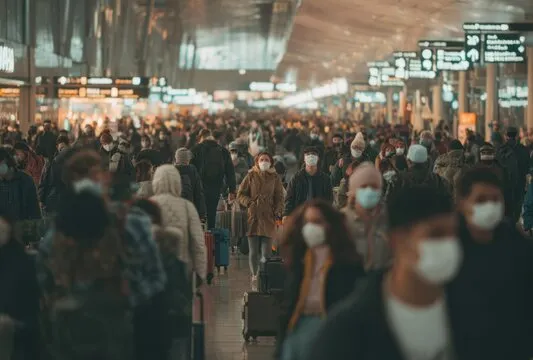
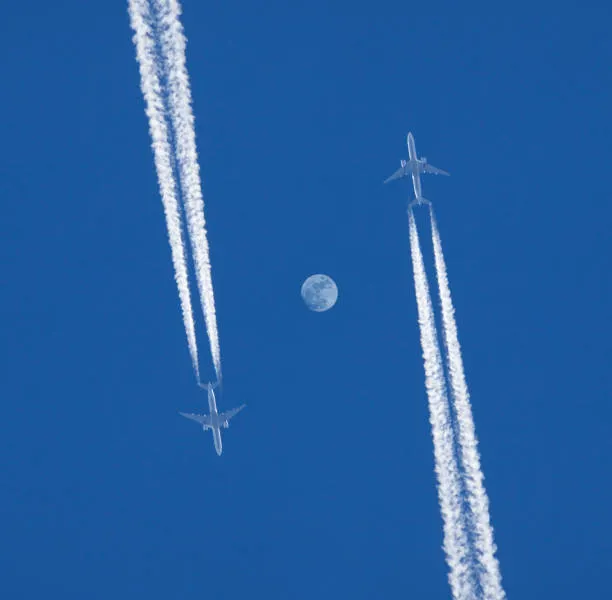

In [13]:
import base64

def img_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

img1 = img_to_base64("360_F_1999806289_qIUBMqNwG6WP0eIUhVaiZi6WdFSeD10M.png")
img2 = img_to_base64("two-jet-planes.png")

display(HTML(f"""
<div style="display:flex; justify-content:center; gap:30px; align-items:flex-start;">
    <div style="text-align:center; width:450px;">
        <img src="data:image/png;base64,{img1}" style="height:350px; width:auto;">
        <p><b>Fig 4a.</b> Busy airport.</p>
    </div>
    <div style="text-align:center; width:450px;">
        <img src="data:image/png;base64,{img2}" style="height:350px; width:auto;">
        <p><b>Fig 4b.</b> Aircraft contrails.</p>
    </div>
</div>
"""))


The evidence in this data story supports parts of both perspectives. Passenger numbers in the EU27 increased from around 710 million in 2008 to more than 1 billion in 2019, while airports dominated by low-cost carriers generally grew faster than traditional hubs. The strongest growth was concentrated in Central and Eastern Europe, where airlines such as Ryanair and Wizz Air expanded aggressively and opened routes that previously did not exist or were significantly more expensive. Taken together, these results suggest that low-cost carriers did not simply redistribute existing passengers between airlines; they contributed to a substantial expansion of the European air travel market.

The environmental results show a similar pattern of growth. European aviation CO₂ emissions increased from approximately 163 million tonnes in 2010 to more than 211 million tonnes in 2019. Although aircraft became more efficient over time, those improvements were not large enough to offset the increase in passenger demand and flight activity. The indexed comparison between passengers and emissions showed that both measures followed very similar trajectories throughout most of the study period.

The country-level results reinforce this relationship. Many of the countries that experienced the strongest passenger growth, including Poland and Ireland, also recorded some of the largest increases in aviation emissions. The same regions that benefited most from the expansion of low-cost air travel were often the regions where aviation activity grew most rapidly.

Overall, the findings suggest that low-cost carriers increased access to air travel for millions of people across Europe, particularly in markets that were previously less connected. At the same time, that growth was associated with higher aviation emissions. The data does not indicate that one perspective is correct and the other is wrong. Instead, it suggests that both outcomes occurred simultaneously: air travel became more accessible, and the environmental footprint of European aviation increased alongside it.

---

## Reflection

### Design justifications

**Figure 1 - Dual-axis line chart.** The central question this figure needs to answer is not just how many passengers there were, but whether growth in passengers was matched by equal growth in flights. Two variables with different units and very different magnitudes are being compared over the same time period. A dual-axis line chart is appropriate here because the goal is to show co-movement rather than absolute comparison, and both series share the same temporal axis. A solid line is used for passengers and a dashed line for flights, providing a second visual channel beyond colour to distinguish them. This matters for accessibility: readers with colour-vision deficiencies, or readers printing in greyscale, can still tell the two lines apart. Position along a shared time axis is the primary encoding for both series, which is the most accurate channel for showing continuous change over time (Wilke, 2019, Chapter 13). An important design decision was to show both series on the same figure rather than splitting them into two panels. Splitting would have made it harder to read the growing gap between passenger growth and flight growth, which is itself part of the argument.

**Figure 2 - Horizontal bar chart.** The initial design used a slope chart comparing two time points per airport, but this became unreadable when many airports had similar starting values and the lines overlapped heavily. A horizontal bar chart was chosen because it encodes exactly one quantity of interest per airport: the percentage growth between 2004 and 2019. Sorting by growth rate makes the ranking immediately visible without any scanning. Airport names are placed on the y-axis rather than the x-axis because they are long strings that would require rotation or truncation on a vertical bar chart. Colour distinguishes LCC-based from traditional airports using the same blue and orange palette used throughout the notebook, so the colour meaning carries over without a separate explanation. A key design choice was to exclude Frankfurt Hahn and Girona, which both declined due to Ryanair relocating its operations rather than due to market weakness. Including them would have distorted the message by making LCC airports appear on average weaker than they were.

**Figure 3 - Animated choropleth.** When the argument concerns where growth happened geographically, a map is the right encoding because position is used to represent position, which is the most direct possible correspondence between data and visual form (Wilke, 2019, Chapter 15). A sequential blue colour scale was chosen rather than a diverging scale because the variable, passenger growth relative to 2004, has no meaningful midpoint. All values above 100 represent growth; there is no case where being darker means something conceptually different from being lighter. The animation over time is the most important design decision in this figure. A static map at a single year would show the geography of growth but not its timing. The slider reveals that the LCC expansion into Central and Eastern Europe happened in a specific wave from 2005 onward, which a static view cannot convey. This makes the interaction genuinely informative rather than decorative. The Play button was added to provide a guided, linear path through the animation for readers who prefer an author-driven experience, while the slider allows readers to explore specific years independently.

**Figure 4 - Indexed line chart.** Passenger numbers and CO₂ emissions are measured in entirely different units and at different absolute scales. Placing them on a dual-axis chart would allow the visual relationship between the lines to be manipulated arbitrarily by choosing different axis ratios. Indexing both to 100 in 2013 removes this ambiguity: both lines start at the same point and any divergence is genuinely meaningful. Position along a shared y-axis then encodes the growth rate of each series, which is the quantity of interest. A horizontal dashed reference line at 100 provides a zero-growth anchor so readers can immediately see whether a series is above or below its baseline without reading the axis. The COVID shaded region is included because omitting it would cause the sharp 2020 dip to look like a data error rather than a documented external event. This is an application of the principle that context which prevents misreading is part of good chart design.

**Figure 5 - Two-panel chart combining bar and line.** This figure shows two related but conceptually distinct measures: total CO₂ output and CO₂ per flight movement. They were placed in separate panels rather than on a dual axis for a specific reason: the two measures are answering different questions. The bar chart in the top panel answers whether the total grew; the line chart in the bottom panel answers whether individual flights became more or less polluting. Keeping them visually separate reinforces the conceptual separation. Bars are used for the annual totals because bars are suited to showing discrete yearly amounts and their length encodes magnitude in a way that is easy to compare across years. A line is used for the per-flight ratio because it is a continuous derived measure where the trend over time matters more than any single year's value, and lines are the natural encoding for showing a trend (Wilke, 2019, Chapter 13). The COVID years are shown in grey rather than omitted, so that the magnitude of the collapse is visible without distorting the pre- and post-pandemic comparisons.

**Figure 6 - Horizontal bar chart (CO₂ growth by country).** The design logic mirrors Figure 2: country names are long, so a horizontal orientation keeps them readable. Sorting by growth rate places the highest-growth countries at the top, which is also where the eye naturally looks first. A vertical reference line at the European average provides a benchmark that turns each bar from an isolated data point into a relative statement. Countries above the line can be immediately identified without reading any numbers. The colour scheme pink for above-average and grey for below-average is consistent with the CO₂-related pink used in Figures 4 and 5, which helps readers connect this chart to the earlier emissions evidence without an explicit instruction to do so.

**Colour choices across all figures.** A single IBM colour-blind-safe palette was applied across all six figures. Blue encodes passenger and LCC-related data, orange encodes traditional carrier data and flight movements, pink encodes CO₂ emissions, and purple encodes derived efficiency metrics. Using the same colour for the same concept throughout means readers only need to learn the colour scheme once. This is consistent with the pre-attentive processing principle: colour used consistently becomes a low-effort lookup rather than a decoding task (Wilke, 2019, Chapter 4). The palette was specifically chosen to be distinguishable for the most common forms of colour-vision deficiency, which affects approximately 8% of male readers.

### How to avoid visualisation problems

| Problem | How it was handled |
|---|---|
| VF1 - bad colour choices | IBM colour-blind-safe palette used throughout; hue never encodes a quantity with natural ordering |
| VF2 - figures too small or too large | All figures between 460 and 600 pixels tall; all axis labels readable |
| VF3 - confusing charts | No more than two series per panel; every axis labelled with its unit |
| VF4 - interaction that adds nothing | Figure 3 uses a year slider to show geographic spread over time, which a static map cannot show |
| VF5 - wrong number of charts | Exactly 6 visualisation components |
| VF6 - too little variety | Six chart types: dual-axis line, horizontal bar chart, animated choropleth map, indexed line, two-panel bar and line, horizontal bar chart (CO2 by country). Figures 1, 4, 5, and 6 are multivariate |

### Reflection on peer and TA feedback

The draft version of this story was presented during the seminar and received feedback from both the TA and peers. Two areas stood out as needing the most work.

The first was coherency. Tycho noted that it was not clear enough how the two perspectives connected. Both sides of the story were told independently, but the link between them, the fact that passenger growth and emissions growth are not two separate phenomena but the same phenomenon counted differently, was not visible enough in the structure of the notebook. A bubble scatter plot that had been used for Figure 6 was also flagged as too difficult to read on its own: the circles were not labelled and the message was not clear without significant interpretation effort.

In response to this, two concrete changes were made. A bridging section was added between the two perspectives explicitly connecting the access story to the emissions story, using the Bergamo airport growth as a specific example of how the same event looks different depending on which unit you use to measure it. Figure 4, the indexed passenger versus CO₂ chart, was given more prominence and placed at the start of Perspective 2 to make it immediately clear that the two measures track each other. Figure 6 was replaced entirely: the bubble scatter was removed and replaced with a horizontal bar chart showing CO₂ growth by country between 2013 and 2019. This chart is self-contained and readable without context, and it creates a direct geographic link back to Figure 3, where the same countries appear as the darkest on the animated map.

The second piece of feedback concerned Figure 2. The original version was a slope chart comparing airport passenger volumes at two points in time. With 23 airports plotted, the lines overlapped heavily in the middle of the chart and the message, that LCC-based airports grew much faster than traditional ones, was hard to extract. The suggestion was to simplify the chart entirely and focus only on the growth rate as the single quantity of interest. Figure 2 was therefore redesigned as a horizontal bar chart sorted by growth percentage, with colour distinguishing airport type. This version communicates the core finding immediately: the bars for LCC-based airports are grouped at the top of the chart, and every traditional airport bar, though positive, is shorter.

---
## Limitations and Future Research 

This data story shows that low-cost carriers were associated with substantial growth in European air travel and that aviation CO₂ emissions increased alongside that growth. However, several limitations prevent stronger conclusions about causality.

The main limitation is the lack of carrier-level data. The Eurostat datasets used in this project do not distinguish between low-cost and traditional airlines, so airports were classified based on their dominant type of traffic. A more detailed analysis could use flight-level data from EUROCONTROL to compare emissions, aircraft efficiency, and passenger volumes for specific airlines. This would allow a direct assessment of whether low-cost carriers are significantly more efficient per passenger than traditional carriers.

A second limitation concerns passenger behaviour. The results suggest that low-cost carriers expanded the market rather than simply redistributing existing travellers, but the available data cannot confirm this. Survey data would be needed to determine whether passengers were making entirely new trips or switching from other transport modes.

Finally, this project does not consider rail as an alternative form of transport. Many European routes can also be served by rail, which generally produces much lower emissions than flying. Future research could examine where low-cost airline routes overlap with rail networks and whether improvements in rail pricing, infrastructure, or ticketing could provide similar accessibility benefits with a lower environmental impact.

Overall, the findings support both perspectives examined in this report, but additional data would be needed to determine the extent to which low-cost carriers directly caused the observed changes in passenger demand and emissions.


---

## Work distribution

| Team member | Contributions |
|---|---|
| Luca Verlaan (16451546) | Euro-stat & -control Dataset, Notebook creation & coding, Discussions |
| Kyano de Kleijn (16377648) | Figure Sketching, General advice |
| Timo Postma (16440323) | Proof-reading, Feedback |
| Tim Snijder (16390164) | LCC Dataset, Jupyter book URL, Sparring discussions |

---

## References

Dobruszkes, F. (2013). The geography of European low-cost airline networks: a contemporary analysis. *Journal of Transport Geography*, *28*, 75-88. https://doi.org/10.1016/j.jtrangeo.2012.10.012

Doganis, R. (2010). *Flying off course: Airline economics and marketing* (4th ed.). Routledge.

European Environment Agency. (2022). *Aviation and shipping: Impacts on Europe's environment* (EEA Report No. 22/2022).

Eurostat. (2025). *Air passenger transport by type of schedule, transport coverage and country*. European Commission.

Eurostat. (2025). *Aircraft traffic data by reporting country*. European Commission.

Eurostat. (2025). *Air passenger transport by type of schedule, transport coverage and main airports*. European Commission.

EUROCONTROL. (2025). *Aviation CO2 emissions by ECAC state, 2010-2025*. EUROCONTROL Aviation Sustainability Unit.

Francis, G., Humphreys, I., Ison, S., & Aicken, M. (2006). Where next for low cost airlines? A spatial and temporal comparative study. *Journal of Transport Geography*, *14*(2), 83-94. https://doi.org/10.1016/j.jtrangeo.2005.08.003

Graham, A., & Dennis, N. (2010). The impact of low cost airline operations to airports. *Journal of Air Transport Management*, *16*(2), 61-67. https://doi.org/10.1016/j.jairtraman.2009.06.001

IATA. (2020). *20 years of low-cost carriers: How LCCs changed aviation*. IATA Economics.

Koo, T. T. R., Lim, C., & Dobruszkes, F. (2013). Causality in direct air services and tourism demand. *Annals of Tourism Research*, *40*, 254-256.

Lee, D. S., Fahey, D. W., Skowron, A., Allen, M. R., Burkhardt, U., Chen, Q., Doherty, S. J., Freeman, S., Forster, P. M., Fuglestvedt, J., Gettelman, A., De Leon, R. R., Lim, L. L., Lund, M. T., Millar, R. J., Owen, B., Penner, J. E., Pitari, G., Prather, M. J., & Wilcox, L. J. (2021). The contribution of global aviation to anthropogenic climate forcing for 2000 to 2018. *Atmospheric Environment*, *244*, Article 117834. https://doi.org/10.1016/j.atmosenv.2020.117834

Peeters, P., Higham, J., Kutzner, D., Cohen, S., & Gossling, S. (2016). Are technology myths stalling aviation climate policy? *Transportation Research Part D: Transport and Environment*, *44*, 30-42. https://doi.org/10.1016/j.trd.2016.02.004

Segel, E., & Heer, J. (2010). Narrative visualization: Telling stories with data. *IEEE Transactions on Visualization and Computer Graphics*, *16*(6), 1139-1148.

Vowles, T. M. (2001). The "Southwest Effect" in multi-airport regions. *Journal of Air Transport Management*, *7*(4), 251-258.

Wilke, C. O. (2019). *Fundamentals of data visualization: A primer on making informative and compelling figures*. O'Reilly Media.

**Images**

Figure 1: Ryanair aircraft at a European airport. Getty Images. https://www.gettyimages.com.mx/fotos/ryanair

Figure 2: Airport departure board. Shutterstock. https://www.shutterstock.com/nl/video/clip-9244772-airport-departure-board

Figure 3: Aircraft contrails visible in the upper atmosphere. Getty Images. https://www.gettyimages.nl/fotos/contrails

Figure 4a: Busy airport terminal crowd. Adobe Stock. https://stock.adobe.com/search?k=airport+terminal+crowd&asset_id=1999806289

Figure 4b: Aircraft contrails. Getty Images. https://www.gettyimages.nl/fotos/contrails
